# Team Clustering

**What this notebook does:** groups historical tournament teams into clusters based on the
features already developed throughout this project — Seed, WinPct, AvgMargin, Elo, and
ConfStrength — to see what natural tiers exist among them, without deciding those tiers in
advance. Every calculation reuses exactly what's already been built in notebooks 03-13; nothing
new is computed from the raw data, only how it gets used changes.

**How this differs from every previous notebook:** every earlier notebook was supervised — it
learned from known win/loss outcomes to predict a probability. This one is unsupervised: it never
looks at who actually won any game. It only looks at how similar or different teams are to each
other across the five features, and groups the similar ones together. There is no prediction and
no Brier score here — clustering answers "what types of team exist," not "who wins."

## 1. Load data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_conf_teams = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_conf_teams = pd.read_csv(DATA_DIR / "WTeamConferences.csv")
m_teams = pd.read_csv(DATA_DIR / "MTeams.csv")
w_teams = pd.read_csv(DATA_DIR / "WTeams.csv")

team_names = pd.concat([
    m_teams[["TeamID", "TeamName"]], w_teams[["TeamID", "TeamName"]]
], ignore_index=True).set_index("TeamID")["TeamName"]

print(f"team name lookup rows: {len(team_names):,}")


team name lookup rows: 760


## 2. Rebuild the five features — this time per team, not per matchup

Every previous notebook used *differences* between two teams (`SeedDiff`, `EloDiff`, etc.),
because the task was predicting one team beating another. Clustering needs each team's own raw
values instead, since the question now is what a team looks like on its own, not how it compares
to one specific opponent. The calculations themselves (win rate, scoring margin, Elo, conference
strength) are identical to notebooks 03-13.

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        WinPct=("Win", "mean"), AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats[["Season", "TeamID", "WinPct", "AvgScoreMargin"]]

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)

def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)

def compute_elo(compact_df, k=20, home_adv=100, mean_reversion=0.75):
    elo = {}
    elo_by_season_end = {}
    for season in sorted(compact_df["Season"].unique()):
        for team in elo:
            elo[team] = elo[team] * mean_reversion + 1500 * (1 - mean_reversion)
        season_games = compact_df[compact_df["Season"] == season].sort_values("DayNum")
        for game in season_games.itertuples(index=False):
            w_, l_ = game.WTeamID, game.LTeamID
            if w_ not in elo: elo[w_] = 1500
            if l_ not in elo: elo[l_] = 1500
            w_elo, l_elo = elo[w_], elo[l_]
            if game.WLoc == "H": w_elo += home_adv
            elif game.WLoc == "A": l_elo += home_adv
            w_exp = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            mov = game.WScore - game.LScore
            mov_mult = np.log(max(mov, 1) + 1) * (2.2 / ((w_elo - l_elo) * 0.001 + 2.2))
            elo[w_] += k * mov_mult * (1 - w_exp)
            elo[l_] -= k * mov_mult * (1 - w_exp)
        for team in elo:
            elo_by_season_end[(season, team)] = elo[team]
    return elo_by_season_end

elo_idx = pd.Series({**compute_elo(m_reg), **compute_elo(w_reg)})
elo_idx.index = pd.MultiIndex.from_tuples(elo_idx.index, names=["Season", "TeamID"])

conf_teams = pd.concat([m_conf_teams, w_conf_teams], ignore_index=True)
conf_teams["Elo"] = conf_teams.apply(lambda r: elo_idx.get((r["Season"], r["TeamID"]), np.nan), axis=1)
conf_teams_valid = conf_teams.dropna(subset=["Elo"])
conf_strength = conf_teams_valid.groupby(["Season", "ConfAbbrev"])["Elo"].mean().rename("ConfStrength")
team_conf_strength = conf_teams_valid.merge(conf_strength, on=["Season", "ConfAbbrev"], how="left")

print("team-season pieces ready: win rate/margin, seeds, Elo, conference strength")


team-season pieces ready: win rate/margin, seeds, Elo, conference strength


## 3. Assemble the team-season table

One row per tournament team per season — every team that has a seed that year, joined with its
own win rate, scoring margin, Elo rating, and conference strength. Restricted to tournament teams
specifically (not every Division I team), since those are the ones with a seed and the ones this
whole project has been trying to say something about.

In [3]:
team_season = seeds.merge(team_stats, on=["Season", "TeamID"], how="left")
team_season["Elo"] = team_season.apply(lambda r: elo_idx.get((r["Season"], r["TeamID"]), np.nan), axis=1)
team_season = team_season.merge(
    team_conf_strength[["Season", "TeamID", "ConfStrength"]], on=["Season", "TeamID"], how="left"
)
team_season["TeamName"] = team_season["TeamID"].map(team_names)

FEATURES = ["SeedNum", "WinPct", "AvgScoreMargin", "Elo", "ConfStrength"]
before = len(team_season)
team_season = team_season.dropna(subset=FEATURES).reset_index(drop=True)
print(f"team-season rows: {before:,}, after dropping missing features: {len(team_season):,}")
print(team_season[["Season", "TeamName"] + FEATURES].head(5).to_string(index=False))


team-season rows: 4,506, after dropping missing features: 4,506
 Season       TeamName  SeedNum   WinPct  AvgScoreMargin         Elo  ConfStrength
   1985     Georgetown        1 0.925926       15.666667 1889.633858   1618.159171
   1985   Georgia Tech        2 0.774194        9.354839 1743.828317   1647.311011
   1985       Illinois        3 0.741935       10.870968 1732.438976   1605.191789
   1985 Loyola-Chicago        4 0.833333        6.766667 1770.888134   1516.063865
   1985            SMU        5 0.733333        8.666667 1616.847418   1549.668209


## 4. Standardize features

`Elo` and `ConfStrength` sit on a scale of hundreds, `SeedNum` runs 1-16, `WinPct` is between 0
and 1, and `AvgScoreMargin` is roughly -20 to +20. Without putting all five on the same scale,
distance-based clustering would end up almost entirely driven by whichever feature happens to
have the largest raw numbers (Elo), regardless of how meaningful the others are. Standardizing
(subtracting the mean, dividing by the standard deviation) puts every feature on equal footing —
each one measured in "how many standard deviations from average," rather than its own natural
units.

In [4]:
X_raw = team_season[FEATURES].values
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

print("feature means (raw):", np.round(X_mean, 2))
print("feature std devs (raw):", np.round(X_std, 2))
print("standardized feature means (should be ~0):", np.round(X.mean(axis=0), 4))


feature means (raw): [8.61000e+00 7.40000e-01 9.06000e+00 1.76655e+03 1.58366e+03]
feature std devs (raw): [4.6400e+00 1.0000e-01 5.4000e+00 1.2638e+02 1.2285e+02]
standardized feature means (should be ~0): [0. 0. 0. 0. 0.]


## 5. K-means clustering (hand-written)

No scikit-learn in this sandbox, so k-means is implemented directly: pick a number of cluster
centers, assign every team to whichever center it's closest to, move each center to the average
position of the teams assigned to it, and repeat until nothing changes. Centers are initialized
by picking random teams as starting points (a fixed random seed is used so this is reproducible).

In [5]:
def kmeans(X, k, n_iter=200, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    centers = X[rng.choice(n, size=k, replace=False)].copy()
    labels = np.zeros(n, dtype=int)
    for _ in range(n_iter):
        dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        new_labels = np.argmin(dists, axis=1)
        if np.array_equal(new_labels, labels) and _ > 0:
            break
        labels = new_labels
        for j in range(k):
            if np.any(labels == j):
                centers[j] = X[labels == j].mean(axis=0)
    dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    inertia = np.sum(np.min(dists, axis=1) ** 2)
    return labels, centers, inertia

print("k-means function ready")


k-means function ready


## 6. Choosing how many clusters (elbow method)

Running k-means for a range of cluster counts and tracking "inertia" (how far, on average, teams
sit from their assigned cluster's center) shows the trade-off directly: more clusters always
reduces inertia, but with diminishing returns. The elbow method picks the point where adding
another cluster stops helping much — the "elbow" of the curve.

inertia by k: {2: np.float64(13295.3), 3: np.float64(9438.7), 4: np.float64(7011.7), 5: np.float64(6233.6), 6: np.float64(5054.0), 7: np.float64(4549.4), 8: np.float64(4183.5)}
relative improvement per added cluster: [np.float64(0.29), np.float64(0.257), np.float64(0.111), np.float64(0.189), np.float64(0.1), np.float64(0.08)]

chosen k = 6 (first point where adding another cluster improves inertia by less than 10%)


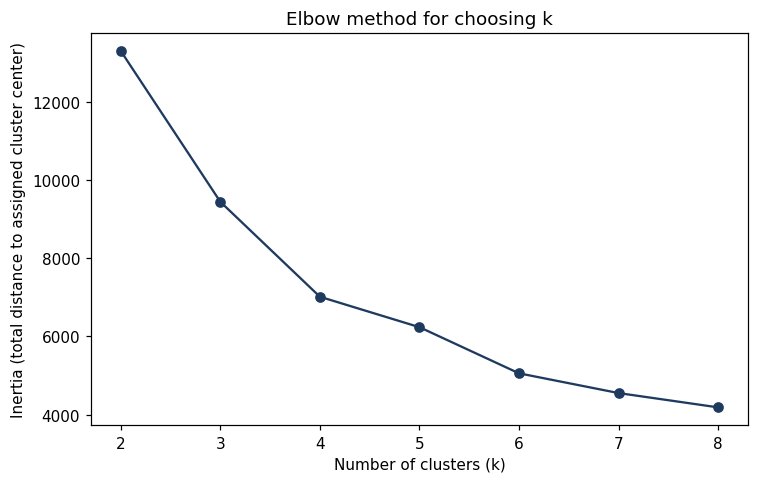

In [6]:
K_RANGE = range(2, 9)
inertias = []
for k in K_RANGE:
    _, _, inertia = kmeans(X, k)
    inertias.append(inertia)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(list(K_RANGE), inertias, marker="o", color="#1f3a5f")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (total distance to assigned cluster center)")
ax.set_title("Elbow method for choosing k")
fig.tight_layout()
plt.show()

# pick k where the relative improvement from adding one more cluster first drops below 10%
pct_improvement = [(inertias[i-1] - inertias[i]) / inertias[i-1] for i in range(1, len(inertias))]
chosen_k = next((list(K_RANGE)[i] for i, p in enumerate(pct_improvement) if p < 0.10), list(K_RANGE)[-1])
print("inertia by k:", {k: round(v, 1) for k, v in zip(K_RANGE, inertias)})
print("relative improvement per added cluster:", [round(p, 3) for p in pct_improvement])
print(f"\nchosen k = {chosen_k} (first point where adding another cluster improves inertia by less than 10%)")


## 7. Final clustering and cluster characterization

Running k-means at the chosen k, then looking at each cluster's average (raw, not standardized)
feature values — this is what turns "cluster 2" into something meaningful, like "low seed, high
Elo, strong conference."

In [7]:
labels, centers, inertia = kmeans(X, chosen_k)
team_season["Cluster"] = labels

cluster_profile = team_season.groupby("Cluster")[FEATURES].mean().round(2)
cluster_profile["NumTeams"] = team_season.groupby("Cluster").size()
cluster_profile = cluster_profile.sort_values("Elo", ascending=False)
print(cluster_profile.to_string())


         SeedNum  WinPct  AvgScoreMargin      Elo  ConfStrength  NumTeams
Cluster                                                                  
5           1.93    0.89           18.98  1995.57       1665.23       438
1           4.10    0.77           10.91  1844.98       1678.36      1040
2          10.61    0.83           12.24  1794.01       1488.84       686
3           8.40    0.66            6.03  1732.25       1668.27      1207
0          13.74    0.72            6.73  1669.37       1446.58       740
4          15.40    0.57            1.26  1545.26       1406.86       395


## 8. Visualizing the clusters (PCA)

Five features can't be plotted directly, so PCA (principal component analysis) compresses them
down to the 2 directions that capture the most variation across all teams, for a scatter plot.
PCA itself is hand-written here too: center the data, compute its covariance matrix (how much
each feature varies together with each other feature), and find the two directions (eigenvectors)
along which the data spreads out the most.

variance captured by the 2 plotted dimensions: 67.9% + 23.8% = 91.7%


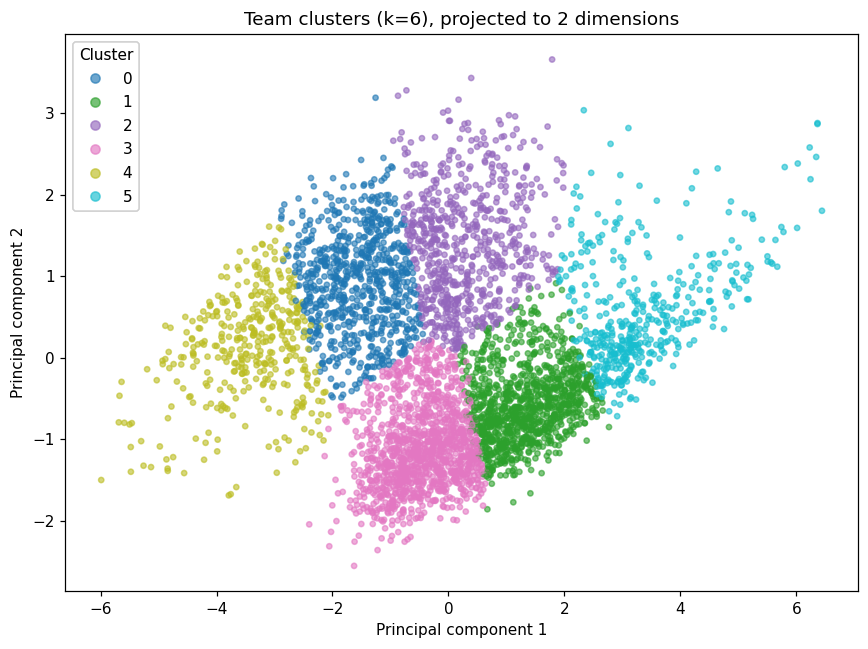

In [8]:
def pca_2d(X):
    X_centered = X - X.mean(axis=0)
    cov = np.cov(X_centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    top2 = eigvecs[:, order[:2]]
    explained = eigvals[order[:2]] / eigvals.sum()
    return X_centered @ top2, explained

coords, explained = pca_2d(X)
print(f"variance captured by the 2 plotted dimensions: {explained[0]:.1%} + {explained[1]:.1%} = {explained.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=12, alpha=0.6)
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.set_title(f"Team clusters (k={chosen_k}), projected to 2 dimensions")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend1)
fig.tight_layout()
plt.show()


## 9. The 2026 field, by cluster

Which cluster does each real 2026 tournament team fall into? Sorted by seed, so it's easy to spot
teams whose overall profile doesn't match their seed number — a team seeded in the double digits
but clustered alongside the top seeds, or vice versa.

In [9]:
field_2026 = team_season[team_season["Season"] == 2026].sort_values("SeedNum")
display_cols = ["TeamName", "SeedNum", "WinPct", "AvgScoreMargin", "Elo", "ConfStrength", "Cluster"]
print(field_2026[display_cols].round(2).to_string(index=False))


      TeamName  SeedNum  WinPct  AvgScoreMargin     Elo  ConfStrength  Cluster
          Duke        1    0.94           19.15 2065.02       1663.66        5
South Carolina        1    0.91           28.35 2137.75       1756.43        5
      Michigan        1    0.91           17.62 2021.33       1725.78        5
       Arizona        1    0.94           17.35 2038.31       1706.91        5
          UCLA        1    0.97           28.12 2206.13       1725.78        5
         Texas        1    0.91           28.32 2143.99       1756.43        5
       Florida        1    0.79           14.79 1963.10       1756.43        1
   Connecticut        1    1.00           38.38 2204.42       1647.58        5
          Iowa        2    0.81           11.62 1998.12       1725.78        1
    Vanderbilt        2    0.87           19.16 1940.37       1756.43        5
       Houston        2    0.82           14.29 1947.25       1706.91        5
        Purdue        2    0.77           11.51 1912

## Summary

**Six clusters emerged**, chosen via the elbow method (Section 6), and they line up with
recognizable basketball tiers rather than arbitrary groupings — a good sign that the five
features genuinely capture meaningful structure:

- **Cluster 5 — Elite (avg. seed ~2, 89% win rate, +19 margin, Elo ~1996):** the clear top tier,
  438 team-seasons. Overwhelmingly 1-4 seeds.
- **Cluster 1 — Strong, power-conference (avg. seed ~4, 77% win rate, Elo ~1845):** the largest
  cluster (1,040 team-seasons) and notably has the *highest* average conference strength of any
  group — good teams from the toughest leagues.
- **Cluster 2 — Mid-major overachiever (avg. seed ~11, 83% win rate, Elo ~1794, but the *lowest*
  conference strength of the top four clusters):** teams racking up strong records against weaker
  competition — exactly the profile that produces dangerous, hard-to-predict tournament teams.
- **Cluster 3 — Average power-conference team (avg. seed ~8, 66% win rate, but high conference
  strength ~1668):** a middling record earned by playing a difficult schedule.
- **Cluster 0 — Modest record, weaker conference (avg. seed ~14):** low-major and mid-major teams
  with a passable but unremarkable profile.
- **Cluster 4 — Underdog (avg. seed ~15, 57% win rate, +1 margin, lowest Elo and conference
  strength):** the bottom tier, the expected home for most 15/16 seeds.

The PCA visualization in Section 8 captures 91.7% of the variation across all five features in
just its two plotted dimensions, so the scatter plot is a faithful picture, not a distortion.

**One concrete finding worth calling out from the 2026 field (Section 9):** Fairleigh Dickinson,
seeded 15th, lands in Cluster 2 (the "mid-major overachiever" tier) rather than Cluster 4 (where
almost every other 15/16 seed falls) — driven by an 88% win rate and a strong +15.84 average
margin, despite the lowest conference strength in the field. This is the same team the original
EDA flagged as having an unusually large gap between its seed and its power ranking. Several
1- and 2-seeds also fell into Cluster 1 rather than Cluster 5 (Florida, Iowa, Purdue, Iowa State,
and Connecticut's 2-seed profile), suggesting the selection committee's seeding and this
feature-based clustering don't always agree on exactly how elite a team is, even among the top
seeds.